In [1]:

from nanodrz.data import libritts_test, artificial_diarisation_sample
from nanodrz.utils import visualise_annotation, play

22.3994375


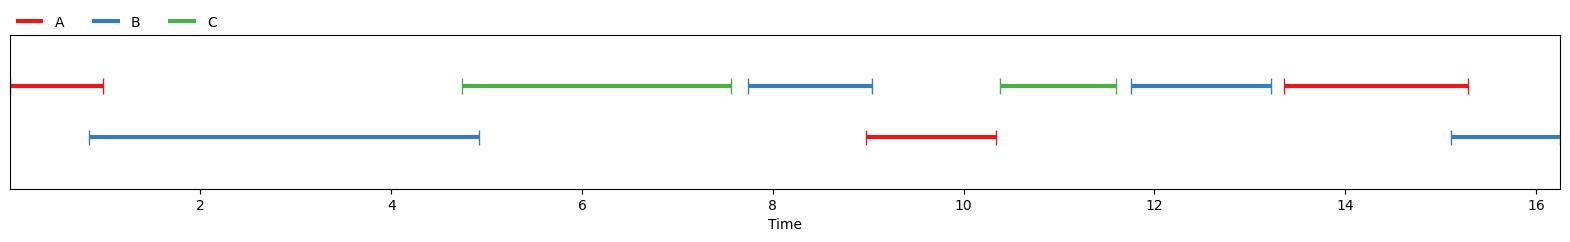

[[0.0027210884353741495, 0.974920634920635, 'A'],
 [0.8274829931972789, 4.088526077097506, 'B'],
 [4.746757369614513, 2.816145124716553, 'C'],
 [7.741224489795918, 1.3022222222222222, 'B'],
 [8.981768707482992, 1.357687074829932, 'A'],
 [10.380725623582766, 1.2127891156462585, 'C'],
 [11.75814058956916, 1.4602721088435373, 'B'],
 [13.363809523809524, 1.9301587301587302, 'A'],
 [15.106303854875284, 1.1472562358276643, 'B']]

In [2]:
# Use the same parameters that the model was trained on to generate a sample
audio, labels = artificial_diarisation_sample(libritts_test(), sr=22050)
print(audio.shape[-1]/16000)
reference = visualise_annotation(labels)
play(audio, 22050)
labels

In [7]:
from torchaudio.transforms import MelSpectrogram
from torch import Tensor
import torch
from librosa.filters import mel as librosa_mel_fn

In [8]:
def mel_spec(
    audio: Tensor,
    num_mels: int = 80,
    n_fft: int = 1024,
    sampling_rate: int = 22050,
    hop_size: int = 256,
    win_size: int = 1024,
    fmin: int = 0,
    fmax: int = 8000,
) -> Tensor:
    mel_basis = {}
    hann_window = {}
    center = False

    if torch.min(audio) < -1.0:
        print("min value is ", torch.min(audio))
    if torch.max(audio) > 1.0:
        print("max value is ", torch.max(audio))

    if fmax not in mel_basis:
        mel = librosa_mel_fn(sr=sampling_rate, n_fft=n_fft, n_mels=num_mels, fmin=fmin, fmax=fmax)
        mel_basis[str(fmax) + "_" + str(audio.device)] = torch.from_numpy(mel).float().to(audio.device)
        hann_window[str(audio.device)] = torch.hann_window(win_size, device=audio.device)

    y = torch.nn.functional.pad(
        audio.unsqueeze(1),
        (int((n_fft - hop_size) / 2), int((n_fft - hop_size) / 2)),
        mode="reflect",
    )

    y = y.squeeze(1)

    spec = torch.stft(
        y,
        n_fft,
        hop_length=hop_size,
        win_length=win_size,
        window=hann_window[str(y.device)],
        center=center,
        pad_mode="reflect",
        normalized=False,
        onesided=True,
        return_complex=False,
    )
    spec = torch.sqrt(spec.pow(2).sum(-1) + (1e-9))
    spec = torch.matmul(mel_basis[str(fmax) + "_" + str(y.device)], spec)
    # dynamic_range_compression
    spec = torch.log(torch.clamp(spec, min=1e-5))

    return spec

In [33]:
from typing import Optional
import matplotlib.pyplot as plt


def plot_spectrogram_to_numpy(
    spectrogram, title: Optional[str] = None, output_path: Optional[str] = None
):
    _, ax = plt.subplots(figsize=(12, 3))
    im = ax.imshow(spectrogram, aspect="auto", origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax)
    plt.xlabel("frames")
    plt.ylabel("channels")
    plt.tight_layout()

    if title:
        plt.title(title)

    plt.show()

max value is  tensor(1.0243)


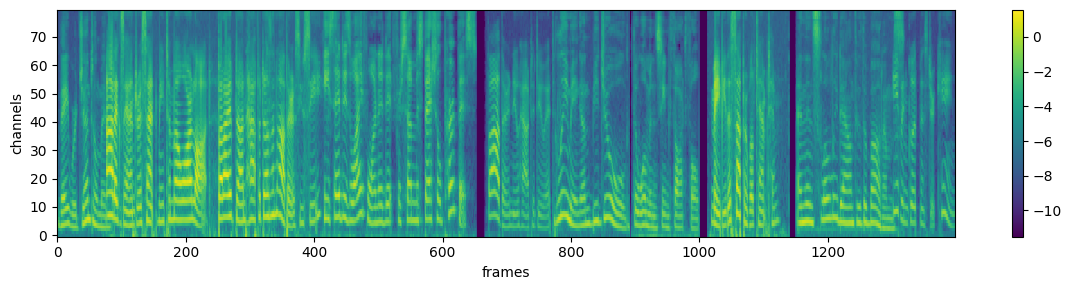

In [34]:
plot_spectrogram_to_numpy(mel_spec(audio)[0])